# 문제 2 — 회전 행렬 구현과 합성 순서 검증

축별 회전 행렬 `rot_x`, `rot_y`, `rot_z` 를 직접 구현하고,
회전이 갖는 성질들을 행렬과 그림 양쪽으로 확인합니다.

## 이 노트북에서 해야 할 일

| # | 할 일 | 구현할 함수 |
|---|---|---|
| 2-1 | 축별 회전 행렬을 만들고 `rot_z(22.5도)` 가 (1,0,0) 을 어디로 보내는지 확인 | `rot_x`, `rot_y`, `rot_z` |
| 2-2 | 세 축 회전을 **Matplotlib 3D 로 그려** 회전축 성분이 보존됨을 눈으로 확인 (그림 코드 제공) | — |
| 2-3 | **합성 순서가 다르면 결과가 달라짐**을 행렬과 **나란히 그린 3D 그림**으로 비교 (그림 코드 제공) | — |
| 2-4 | 세 회전 행렬의 행렬식과 반사 행렬 `diag(1,-1,1)` 의 행렬식을 비교하고 **왜 1 이어야 하는지** 설명 | (문제 1 의 `det`) |
| 2-5 | 문제 1 의 `skew` 로 **로드리게스 공식**을 구현하고 `rot_z` 와 일치하는지 검증 | `rodrigues` |

> 각도는 **라디안**으로 받습니다. 도 단위는 `np.deg2rad` 로 바꿔 넣으세요.
> 순서 의존성 비교 그림은 **반드시 포함**되어야 합니다.
> `# --- 검증 ---` 셀과 3D 그림 셀은 제공된 코드입니다. 수정하지 말고 참조하는 변수 이름을 맞춰 주세요.

In [1]:
%load_ext autoreload
%autoreload

In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.rotation import rodrigues, rot_x, rot_y, rot_z
from src.vectors import det, skew          # 문제 1 에서 만든 함수를 재사용

rng = np.random.default_rng(42)
np.set_printoptions(precision=6, suppress=True)

# 한글 라벨이 깨지지 않도록 폰트 지정 (Windows 기준, 없으면 기본 폰트로 fallback)
for _f in ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]:
    if _f in {f.name for f in __import__("matplotlib").font_manager.fontManager.ttflist}:
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False


def check(label, condition):
    tag = "PASS" if condition else "FAIL"
    print("[" + tag + "] " + label)
    return bool(condition)


# --- 그림 헬퍼 (그대로 쓰면 됩니다) -----------------------------------------

def draw_frame(ax, R=np.eye(3), origin=(0, 0, 0), scale=1.0, alpha=1.0, labels=None):
    """회전 행렬 R 의 세 열을 x(빨강)·y(초록)·z(파랑) 축으로 그린다."""
    origin = np.asarray(origin, dtype=float)
    colors = ["r", "g", "b"]
    names = labels if labels else ["x", "y", "z"]
    for i in range(3):
        v = R[:, i] * scale
        ax.quiver(*origin, *v, color=colors[i], alpha=alpha, arrow_length_ratio=0.15)
        ax.text(*(origin + v * 1.12), names[i], color=colors[i], fontsize=9)


def setup_axes(ax, title, lim=1.3):
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_zlim(-lim, lim)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_title(title, fontsize=10)
    ax.set_box_aspect([1, 1, 1])


print("준비 완료")

준비 완료


## 2-1. 축별 회전 행렬과 `rot_z(22.5도)` 검증

오른손 좌표계에서 각 축 회전 행렬은 다음과 같습니다.

$$R_x(\theta)=\begin{bmatrix}1&0&0\\0&\cos\theta&-\sin\theta\\0&\sin\theta&\cos\theta\end{bmatrix},\quad
R_y(\theta)=\begin{bmatrix}\cos\theta&0&\sin\theta\\0&1&0\\-\sin\theta&0&\cos\theta\end{bmatrix},\quad
R_z(\theta)=\begin{bmatrix}\cos\theta&-\sin\theta&0\\\sin\theta&\cos\theta&0\\0&0&1\end{bmatrix}$$

$R_y$ 만 부호 배치가 뒤집혀 보입니다. 오른손 규칙에서 y축 회전이 어느 축에서
어느 축으로 도는지 생각해 보면 이유를 설명할 수 있습니다.

**할 일** — 세 함수를 구현하고, $R_z(22.5^\circ)$ 를 $(1,0,0)$ 에 적용한 결과를 확인하세요.
결과는 $(\cos 22.5^\circ,\ \sin 22.5^\circ,\ 0)$ 이어야 합니다. 이 값을 **먼저 손으로** 구해 두세요
($\cos 22.5^\circ = \tfrac{\sqrt{2+\sqrt2}}{2}$).

In [3]:
ANG = np.deg2rad(22.5)
p = np.array([1.0, 0.0, 0.0])

# TODO: Rz = rot_z(ANG) 와 p_rot = Rz @ p 를 만들어 출력하세요.
Rz = rot_z(ANG)
print("rot_z(22.5) =\n", Rz)

p_rot = Rz @ p
print("\n(1,0,0) -> ", p_rot)
# TODO: rot_x(ANG), rot_y(ANG) 도 함께 출력해 형태를 확인하세요.
Rx = rot_x(ANG)
Ry = rot_y(ANG)
print("rot_x(22.5) =\n", Rx)
print("rot_y(22.5) =\n", Ry)
# TODO: 손으로 구한 기대값 expected = (cos 22.5°, sin 22.5°, 0) 도 변수로 두세요.
expected = np.array([np.sqrt(2 + np.sqrt(2)) / 2, np.sqrt(2 - np.sqrt(2)) / 2, 0.0])

rot_z(22.5) =
 [[ 0.92388  -0.382683  0.      ]
 [ 0.382683  0.92388   0.      ]
 [ 0.        0.        1.      ]]

(1,0,0) ->  [0.92388  0.382683 0.      ]
rot_x(22.5) =
 [[ 1.        0.        0.      ]
 [ 0.        0.92388  -0.382683]
 [ 0.        0.382683  0.92388 ]]
rot_y(22.5) =
 [[ 0.92388   0.        0.382683]
 [ 0.        1.        0.      ]
 [-0.382683  0.        0.92388 ]]


In [4]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("rot_z(22.5도) @ (1,0,0) == (cos22.5, sin22.5, 0)", np.allclose(p_rot, expected))
ok &= check("손계산 기대값이 (0.923880, 0.382683, 0)", np.allclose(expected, [0.9238795, 0.3826834, 0.0]))
ok &= check("rot_x(22.5도) @ (0,1,0) == (0, cos, sin)",
            np.allclose(rot_x(ANG) @ [0, 1, 0], [0, np.cos(ANG), np.sin(ANG)]))
ok &= check("rot_y(22.5도) @ (0,0,1) == (sin, 0, cos)",
            np.allclose(rot_y(ANG) @ [0, 0, 1], [np.sin(ANG), 0, np.cos(ANG)]))
ok &= check("rot_y(22.5도) @ (1,0,0) == (cos, 0, -sin)  (y축은 z->x 방향으로 돈다)",
            np.allclose(rot_y(ANG) @ [1, 0, 0], [np.cos(ANG), 0, -np.sin(ANG)]))
ok &= check("0도 회전은 단위행렬", np.allclose(rot_z(0.0), np.eye(3)))
ok &= check("R(theta) @ R(-theta) == I", np.allclose(rot_z(0.7) @ rot_z(-0.7), np.eye(3)))
ok &= check("네 번 돌리면 90도: rot_z(22.5)^4 == rot_z(90)",
            np.allclose(np.linalg.matrix_power(rot_z(ANG), 4), rot_z(np.pi / 2)))
ok &= check("회전은 길이를 보존", np.isclose(np.linalg.norm(p_rot), np.linalg.norm(p)))
print("\n2-1 전체 통과:", ok)

[PASS] rot_z(22.5도) @ (1,0,0) == (cos22.5, sin22.5, 0)
[PASS] 손계산 기대값이 (0.923880, 0.382683, 0)
[PASS] rot_x(22.5도) @ (0,1,0) == (0, cos, sin)
[PASS] rot_y(22.5도) @ (0,0,1) == (sin, 0, cos)
[PASS] rot_y(22.5도) @ (1,0,0) == (cos, 0, -sin)  (y축은 z->x 방향으로 돈다)
[PASS] 0도 회전은 단위행렬
[PASS] R(theta) @ R(-theta) == I
[PASS] 네 번 돌리면 90도: rot_z(22.5)^4 == rot_z(90)
[PASS] 회전은 길이를 보존

2-1 전체 통과: True


## 2-2. 축별 회전 3D 시각화 — 회전축 성분은 보존된다

임의의 점 하나를 각 축 기준으로 0 ~ 360도 돌리면 궤적이 어떤 모양이 되는지,
그리고 **어떤 성분이 변하지 않는지** 그림으로 확인합니다.

아래 그림 셀은 **제공된 코드**입니다. `rot_x/y/z` 만 올바르면 그대로 동작합니다.
그림을 보고 마크다운에 관찰 내용을 적으세요.

### 관찰

- 궤적의 모양: `circle perpendicular to rotation axis`
- 보존되는 성분과 그 이유 (행렬의 어느 행/열 때문인지): `Preserves components parallel to the rotation axis. Rirst, second, third row/comlun of Rx, Ry, Rz is unit vector, respectively.`

/tmp/ipykernel_10227/2006871120.py:26: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_10227/2006871120.py:26: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_10227/2006871120.py:26: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_10227/2006871120.py:26: UserWarning: Glyph 51316 (\N{HANGUL SYLLABLE JON}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_10227/2006871120.py:26: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_10227/2006871120.py:26: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_10227/2006871120.py:26: UserWarning: Glyph 54253 (\N{HANGUL SYLLABLE POG}) missing from font(s) DejaVu Sans.
  f

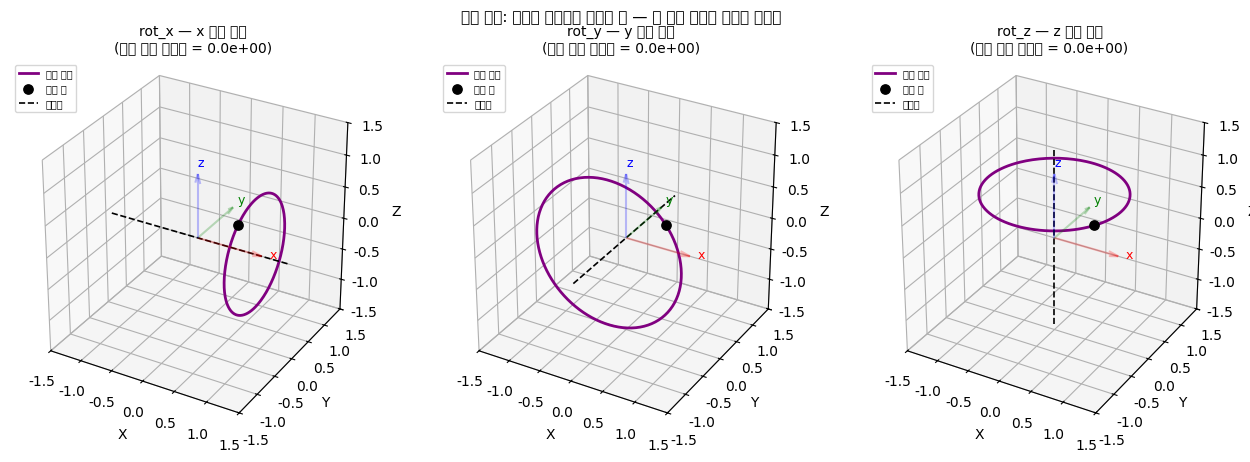

In [5]:
# --- 3D 그림 (제공 코드) ---
p0 = np.array([0.9, -0.5, 0.7])
angles = np.linspace(0, 2 * np.pi, 200)

fig = plt.figure(figsize=(13, 4.4))
info = []       # (이름, 보존 성분의 변화폭) — 검증 셀에서 사용
for k, (name, maker, axis_vec, keep) in enumerate([
    ("rot_x — x 성분 보존", rot_x, [1, 0, 0], 0),
    ("rot_y — y 성분 보존", rot_y, [0, 1, 0], 1),
    ("rot_z — z 성분 보존", rot_z, [0, 0, 1], 2),
]):
    traj = np.array([maker(t) @ p0 for t in angles])
    spread = traj[:, keep].max() - traj[:, keep].min()
    info.append((name, spread))

    ax = fig.add_subplot(1, 3, k + 1, projection="3d")
    setup_axes(ax, name + "\n(보존 성분 변화폭 = {:.1e})".format(spread), lim=1.5)
    draw_frame(ax, scale=1.0, alpha=0.25)
    ax.plot(traj[:, 0], traj[:, 1], traj[:, 2], color="purple", lw=2, label="회전 궤적")
    ax.scatter(*p0, color="k", s=45, label="원래 점")
    av = np.array(axis_vec, dtype=float) * 1.4
    ax.plot([-av[0], av[0]], [-av[1], av[1]], [-av[2], av[2]], "k--", lw=1.2, label="회전축")
    ax.legend(fontsize=7, loc="upper left")

fig.suptitle("축별 회전: 궤적은 회전축에 수직인 원 — 축 방향 성분은 변하지 않는다", fontsize=11)
fig.tight_layout()
plt.show()

In [6]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = True
for name, spread in info:
    ok &= check(name + " : 보존 성분 변화폭 {:.2e} < 1e-12".format(spread), spread < 1e-12)

traj = np.array([rot_z(t) @ p0 for t in angles])
radii = np.linalg.norm(traj, axis=1)
ok &= check("회전 궤적의 모든 점이 원점에서 등거리", np.allclose(radii, np.linalg.norm(p0)))
ok &= check("z축 회전 궤적의 반지름은 sqrt(x0^2 + y0^2)",
            np.allclose(np.linalg.norm(traj[:, :2], axis=1), np.hypot(p0[0], p0[1])))
print("\n2-2 전체 통과:", ok)

[PASS] rot_x — x 성분 보존 : 보존 성분 변화폭 0.00e+00 < 1e-12
[PASS] rot_y — y 성분 보존 : 보존 성분 변화폭 0.00e+00 < 1e-12
[PASS] rot_z — z 성분 보존 : 보존 성분 변화폭 0.00e+00 < 1e-12
[PASS] 회전 궤적의 모든 점이 원점에서 등거리
[PASS] z축 회전 궤적의 반지름은 sqrt(x0^2 + y0^2)

2-2 전체 통과: True


## 2-3. 합성 순서가 다르면 결과가 다르다

행렬 곱은 교환법칙이 성립하지 않습니다: $R_y R_z \neq R_z R_y$.

표기 약속: $R_y R_z \mathbf{p}$ 는 "**$R_z$ 를 먼저**, 그다음 $R_y$" 라는 뜻입니다
(오른쪽 것이 먼저 적용됩니다).

**할 일**

- y축 22.5도와 z축 67.5도를 두 순서로 합성해 결과 행렬 A, B 를 만들고 차이를 출력하세요.
- 아래 3분할 3D 그림(제공)으로 같은 초기 자세가 두 순서로 어떻게 다르게 끝나는지 비교하세요.
- 왜 물리적으로 당연한 결과인지 아래에 적으세요.

### 순서가 결과를 바꾸는 이유

- `Sequences of rotations with different rotation axes reder different outputs.`

In [7]:
ang_y = np.deg2rad(22.5)
ang_z = np.deg2rad(67.5)
test_p = np.array([1.0, 0.0, 0.0])

# TODO: A = rot_y(ang_y) @ rot_z(ang_z)  (z 먼저, 그다음 y)
#       B = rot_z(ang_z) @ rot_y(ang_y)  (y 먼저, 그다음 z)
#       두 행렬과 차이(최대 절댓값)를 출력하세요.
A = rot_y(ang_y) @ rot_z(ang_z)    # z 먼저, 그다음 y
B = rot_z(ang_z) @ rot_y(ang_y)     # y 먼저, 그다음 z

print("rot_y(22.5) @ rot_z(67.5) (z 먼저) =\n", A)
print("\nrot_z(67.5) @ rot_y(22.5) (y 먼저) =\n", B)
print("\n두 결과가 같은가 :", np.allclose(A, B))
print("차이의 최대 절댓값 :", np.max(np.abs(A - B)))
# TODO: test_p 가 두 순서에서 각각 어디로 가는지도 출력하세요.
print("\n(1,0,0) 을 z->y 순서로 :", A @ test_p)
print("(1,0,0) 을 y->z 순서로 :", B @ test_p)

rot_y(22.5) @ rot_z(67.5) (z 먼저) =
 [[ 0.353553 -0.853553  0.382683]
 [ 0.92388   0.382683  0.      ]
 [-0.146447  0.353553  0.92388 ]]

rot_z(67.5) @ rot_y(22.5) (y 먼저) =
 [[ 0.353553 -0.92388   0.146447]
 [ 0.853553  0.382683  0.353553]
 [-0.382683  0.        0.92388 ]]

두 결과가 같은가 : False
차이의 최대 절댓값 : 0.3535533905932738

(1,0,0) 을 z->y 순서로 : [ 0.353553  0.92388  -0.146447]
(1,0,0) 을 y->z 순서로 : [ 0.353553  0.853553 -0.382683]


/tmp/ipykernel_10227/3971625776.py:19: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_10227/3971625776.py:19: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_10227/3971625776.py:19: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_10227/3971625776.py:19: UserWarning: Glyph 49464 (\N{HANGUL SYLLABLE SE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_10227/3971625776.py:19: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_10227/3971625776.py:19: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_10227/3971625776.py:19: UserWarning: Glyph 54665 (\N{HANGUL SYLLABLE HAENG}) missing from font(s) DejaVu Sans.
  fig.tig

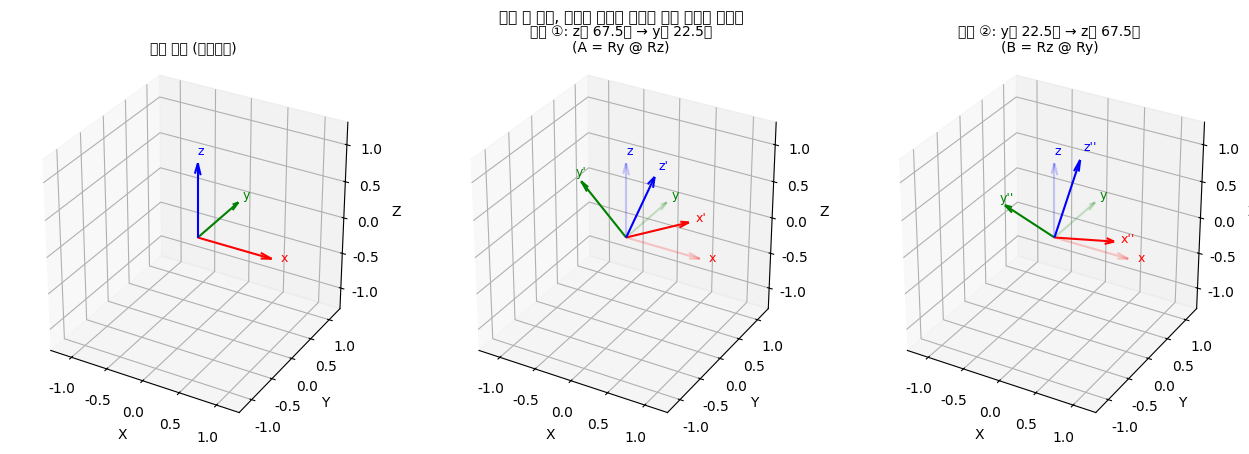

In [8]:
# --- 3D 그림 (제공 코드) ---
fig = plt.figure(figsize=(13, 4.4))

ax = fig.add_subplot(1, 3, 1, projection="3d")
setup_axes(ax, "초기 자세 (단위행렬)")
draw_frame(ax, np.eye(3))

ax = fig.add_subplot(1, 3, 2, projection="3d")
setup_axes(ax, "순서 ①: z축 67.5도 → y축 22.5도\n(A = Ry @ Rz)")
draw_frame(ax, np.eye(3), alpha=0.2)
draw_frame(ax, A, labels=["x'", "y'", "z'"])

ax = fig.add_subplot(1, 3, 3, projection="3d")
setup_axes(ax, "순서 ②: y축 22.5도 → z축 67.5도\n(B = Rz @ Ry)")
draw_frame(ax, np.eye(3), alpha=0.2)
draw_frame(ax, B, labels=["x''", "y''", "z''"])

fig.suptitle("같은 두 회전, 순서만 바꿨을 뿐인데 최종 자세가 다르다", fontsize=11)
fig.tight_layout()
plt.show()

In [9]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("두 합성 결과 행렬이 다르다", not np.allclose(A, B))
ok &= check("A 의 정의가 맞다 (Ry @ Rz)", np.allclose(A, rot_y(ang_y) @ rot_z(ang_z)))
ok &= check("B 의 정의가 맞다 (Rz @ Ry)", np.allclose(B, rot_z(ang_z) @ rot_y(ang_y)))
ok &= check("같은 축끼리는 순서를 바꿔도 같다 (교환 가능)",
            np.allclose(rot_z(0.3) @ rot_z(0.9), rot_z(0.9) @ rot_z(0.3)))
ok &= check("각도가 0 이면 순서가 무의미", np.allclose(rot_y(0.0) @ rot_z(0.5), rot_z(0.5) @ rot_y(0.0)))
ok &= check("두 결과 모두 회전행렬 (det = 1)",
            np.isclose(det(A), 1.0) and np.isclose(det(B), 1.0))
ok &= check("A 와 B 는 서로 다른 곳으로 (1,0,0) 을 보낸다",
            not np.allclose(A @ test_p, B @ test_p))
ok &= check("B 는 (1,0,0) 의 z 성분을 바꾸지 않는다 (y 회전 후 z 회전이라)",
            np.isclose((B @ test_p)[2], -np.sin(ang_y)))
print("\n2-3 전체 통과:", ok)

[PASS] 두 합성 결과 행렬이 다르다
[PASS] A 의 정의가 맞다 (Ry @ Rz)
[PASS] B 의 정의가 맞다 (Rz @ Ry)
[PASS] 같은 축끼리는 순서를 바꿔도 같다 (교환 가능)
[PASS] 각도가 0 이면 순서가 무의미
[PASS] 두 결과 모두 회전행렬 (det = 1)
[PASS] A 와 B 는 서로 다른 곳으로 (1,0,0) 을 보낸다
[PASS] B 는 (1,0,0) 의 z 성분을 바꾸지 않는다 (y 회전 후 z 회전이라)

2-3 전체 통과: True


## 2-4. 행렬식이 1 이어야 하는 이유 — 회전 vs 반사

직교행렬($R^{\mathsf{T}}R=I$)의 행렬식은 $\pm 1$ 뿐입니다.
$\det(R^{\mathsf{T}}R)=\det(R)^2=\det(I)=1$ 이기 때문입니다.

그렇다면 $\det = -1$ 인 직교행렬은 무엇일까요?
대각성분이 $(1,-1,1)$ 인 행렬을 놓고 다음을 직접 확인해 보세요.

- 직교성($S^{\mathsf{T}}S=I$)은 만족하는가
- 행렬식은 얼마인가
- $\mathbf{x}' \times \mathbf{y}' = \mathbf{z}'$ (오른손 규칙)이 유지되는가

세 질문의 답을 모으면 "왜 직교만으로는 부족하고 $\det=+1$ 까지 요구하는가" 가 나옵니다.
로봇 자세에 $\det=-1$ 행렬이 들어가면 실제로 무슨 일이 벌어질지도 함께 적으세요.

### 행렬식이 1 이어야 하는 이유

- 회전 행렬 세 개의 행렬식: `1.0` / 반사 행렬의 행렬식: `-1.0`
- 차이의 의미: `Rotation preserves length, angle, and handedness. Reflection preserves length and angle but it flips the coordinate handedness.`
- 로봇에서의 영향: `Mirrored commands to joints / mirrored proecssing of chains.`

In [10]:
S = np.diag([1.0, -1.0, 1.0])     # y 를 뒤집는 반사 행렬
rows = [("rot_x(0.7)", rot_x(0.7)), ("rot_y(1.2)", rot_y(1.2)),
        ("rot_z(-0.4)", rot_z(-0.4)), ("반사 diag(1,-1,1)", S)]

# TODO: rows 의 각 행렬에 대해 det(직접 구현), 직교 오차 max|M.T @ M - I| 를 표로 출력하세요.
print("{:<20}{:>14}{:>16}".format("행렬", "det", "직교 오차"))
print("-" * 50)
for name, Mx in rows:
    orth_err = np.max(np.abs(Mx.T @ Mx - np.eye(3)))
    print("{:<20}{:>14.6f}{:>16.2e}".format(name, det(Mx), orth_err))
# TODO: 각 행렬에 대해 x' x y' == z' 인지도 함께 출력하세요.
for name, Mx in rows:
    x, y, z = Mx[:, 0], Mx[:, 1], Mx[:, 2]
    print("{:<20} x' x y' == z' ? {}".format(name, np.allclose(np.cross(x, y), z)))

행렬                             det           직교 오차
--------------------------------------------------
rot_x(0.7)                1.000000        2.08e-17
rot_y(1.2)                1.000000        1.11e-16
rot_z(-0.4)               1.000000        2.13e-17
반사 diag(1,-1,1)          -1.000000        0.00e+00
rot_x(0.7)           x' x y' == z' ? True
rot_y(1.2)           x' x y' == z' ? True
rot_z(-0.4)          x' x y' == z' ? True
반사 diag(1,-1,1)      x' x y' == z' ? False


In [11]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("세 회전 행렬의 행렬식이 모두 1",
           all(np.isclose(det(m(t)), 1.0) for m, t in [(rot_x, 0.7), (rot_y, 1.2), (rot_z, -0.4)]))
ok &= check("반사 행렬의 행렬식은 -1", np.isclose(det(S), -1.0))
ok &= check("반사 행렬도 직교이긴 하다", np.allclose(S.T @ S, np.eye(3)))
ok &= check("회전은 오른손 규칙 보존 (x' x y' == z')",
            np.allclose(np.cross(rot_y(1.2)[:, 0], rot_y(1.2)[:, 1]), rot_y(1.2)[:, 2]))
ok &= check("반사는 오른손 규칙을 깬다",
            not np.allclose(np.cross(S[:, 0], S[:, 1]), S[:, 2]))
ok &= check("반사 뒤에 회전을 곱해도 det 는 -1 (회전으로 되돌릴 수 없다)",
            np.isclose(det(rot_z(0.5) @ S), -1.0))
ok &= check("무작위 회전 100개의 det 가 모두 1",
            all(np.isclose(det(rot_z(t1) @ rot_y(t2) @ rot_x(t3)), 1.0)
                for t1, t2, t3 in rng.uniform(-np.pi, np.pi, (100, 3))))
print("\n2-4 전체 통과:", ok)

[PASS] 세 회전 행렬의 행렬식이 모두 1
[PASS] 반사 행렬의 행렬식은 -1
[PASS] 반사 행렬도 직교이긴 하다
[PASS] 회전은 오른손 규칙 보존 (x' x y' == z')
[PASS] 반사는 오른손 규칙을 깬다
[PASS] 반사 뒤에 회전을 곱해도 det 는 -1 (회전으로 되돌릴 수 없다)
[PASS] 무작위 회전 100개의 det 가 모두 1

2-4 전체 통과: True


## 2-5. 로드리게스 공식 — `skew` 로 임의 축 회전

단위 축 $\mathbf{k}$ 를 중심으로 $\theta$ 만큼 도는 회전은

$$R = I + \sin\theta\,[\mathbf{k}]_\times + (1-\cos\theta)\,[\mathbf{k}]_\times^2$$

로 쓸 수 있습니다. 문제 1 에서 만든 `skew` 가 그대로 들어갑니다.
축을 $\mathbf{k}=(0,0,1)$ 로 두면 `rot_z` 와 정확히 같아야 합니다.

**할 일** — `src/rotation.py` 의 `rodrigues` 를 구현하고,
z축·임의 축 두 경우를 확인하세요. 축이 회전 후에도 그대로인지도 봅니다.

In [18]:
theta = np.deg2rad(52.5)
k_raw = np.array([2.0, -1.0, 1.5])        # 정규화되지 않은 임의 축

# TODO: R_rod_z = rodrigues([0, 0, 1], theta) 와 rot_z(theta) 를 비교 출력하세요.
R_rod_z = rodrigues([0, 0, 1], theta)
print("rodrigues(z, 52.5도) =\n", R_rod_z)
print("\nrot_z(52.5도) =\n", rot_z(theta))
print("\n최대 차이 :", np.max(np.abs(R_rod_z - rot_z(theta))))
# TODO: k = k_raw / |k_raw| 로 정규화한 뒤 R_arb = rodrigues(k, theta) 를 만들고,
#       R_arb @ k 가 k 그대로인지 확인하세요.
k = k_raw / np.linalg.norm(k_raw)
R_arb = rodrigues(k, theta)
print("\n임의 축 k =", k)
print("rodrigues(k, 37도) =\n", R_arb)
print("\nR @ k =", R_arb @ k, " (축은 회전해도 그대로여야 함)")
print("축은 회전해도 그대로:", np.allclose(k, R_arb @ k))
# TODO: skew 로 공식을 손으로 조립한 manual 과 R_arb 가 같은지 확인하세요.
K = skew(k)
manual = np.eye(3) + np.sin(theta) * K + (1 - np.cos(theta)) * (K @ K)
print("\n손으로 조립한 공식과 일치 :", np.allclose(manual, R_arb))

rodrigues(z, 52.5도) =
 [[ 0.608761 -0.793353  0.      ]
 [ 0.793353  0.608761  0.      ]
 [ 0.        0.        1.      ]]

rot_z(52.5도) =
 [[ 0.608761 -0.793353  0.      ]
 [ 0.793353  0.608761  0.      ]
 [ 0.        0.        1.      ]]

최대 차이 : 0.0

임의 축 k = [ 0.742781 -0.371391  0.557086]
rodrigues(k, 37도) =
 [[ 0.824617 -0.549894 -0.132752]
 [ 0.334038  0.662725 -0.670234]
 [ 0.456536  0.508342  0.73018 ]]

R @ k = [ 0.742781 -0.371391  0.557086]  (축은 회전해도 그대로여야 함)
축은 회전해도 그대로: True

손으로 조립한 공식과 일치 : True


In [13]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("rodrigues(z축) == rot_z", np.allclose(R_rod_z, rot_z(theta)))
ok &= check("rodrigues(x축) == rot_x", np.allclose(rodrigues([1, 0, 0], theta), rot_x(theta)))
ok &= check("rodrigues(y축) == rot_y", np.allclose(rodrigues([0, 1, 0], theta), rot_y(theta)))
ok &= check("손으로 조립한 공식과 일치", np.allclose(manual, R_arb))
ok &= check("임의 축 결과가 회전행렬 (det = 1)", np.isclose(det(R_arb), 1.0))
ok &= check("임의 축 결과가 직교", np.allclose(R_arb.T @ R_arb, np.eye(3)))
ok &= check("회전축은 변하지 않는다 (R k == k)", np.allclose(R_arb @ k, k))
ok &= check("정규화 안 된 축을 줘도 같은 결과", np.allclose(rodrigues(k_raw, theta), R_arb))
ok &= check("회전각이 대각합에 반영된다: tr(R) = 1 + 2cos(theta)",
            np.isclose(np.trace(R_arb), 1 + 2 * np.cos(theta)))
ok &= check("무작위 축 50개 모두 회전행렬",
            all(np.isclose(det(rodrigues(ax, t)), 1.0)
                for ax, t in zip(rng.standard_normal((50, 3)), rng.uniform(-np.pi, np.pi, 50))))
print("\n2-5 전체 통과:", ok)

[PASS] rodrigues(z축) == rot_z
[PASS] rodrigues(x축) == rot_x
[PASS] rodrigues(y축) == rot_y
[PASS] 손으로 조립한 공식과 일치
[PASS] 임의 축 결과가 회전행렬 (det = 1)
[PASS] 임의 축 결과가 직교
[PASS] 회전축은 변하지 않는다 (R k == k)
[PASS] 정규화 안 된 축을 줘도 같은 결과
[PASS] 회전각이 대각합에 반영된다: tr(R) = 1 + 2cos(theta)
[PASS] 무작위 축 50개 모두 회전행렬

2-5 전체 통과: True


## 답안 템플릿 정리

In [29]:
summary = f"""
1. rot_z(22.5도) 로 변환한 (1,0,0): {p_rot}   (기대값 {expected}, 일치 {np.allclose(p_rot, expected)})

2. 축별 회전 3D 시각화: 위 그림 참조
   - 회전축 방향 성분의 변화폭 — x: {info[0][1]:.1e}, y:  {info[1][1]:.1e}, z:  {info[2][1]:.1e}
   - 관찰: The trace of rotation is a circle perpendicular to the rotation axis.
   The component parallel to the rotation axis is preserved.

3. 합성 순서 비교 — 두 결과 행렬이 다른가: {not np.allclose(A, B)}
   - 최대 성분 차이: {np.max(np.abs(A - B)):.3f} / 비교 그림: 위 3분할 그림
   - 순서가 결과를 바꾸는 이유: Sequences of rotations with different rotation axes reder different outputs.

4. 세 회전 행렬의 행렬식: 1.0 / 반사 행렬 diag(1,-1,1) 의 행렬식: {det(S):.1f}
   - 차이의 의미: Rotation preserves length, angle, and handedness. Reflection preserves length and angle but it flips the coordinate handedness.

5. 로드리게스 구현과 rot_z 일치: {np.allclose(R_rod_z, rot_z(theta))}
   - 임의 축에서도 det=1, 직교, R k = k 확인: {np.allclose(k, R_arb @ k)}
"""
print(summary)


1. rot_z(22.5도) 로 변환한 (1,0,0): [0.92388  0.382683 0.      ]   (기대값 [0.92388  0.382683 0.      ], 일치 True)

2. 축별 회전 3D 시각화: 위 그림 참조
   - 회전축 방향 성분의 변화폭 — x: 0.0e+00, y:  0.0e+00, z:  0.0e+00
   - 관찰: The trace of rotation is a circle perpendicular to the rotation axis.
   The component parallel to the rotation axis is preserved.

3. 합성 순서 비교 — 두 결과 행렬이 다른가: True
   - 최대 성분 차이: 0.354 / 비교 그림: 위 3분할 그림
   - 순서가 결과를 바꾸는 이유: Sequences of rotations with different rotation axes reder different outputs.

4. 세 회전 행렬의 행렬식: 1.0 / 반사 행렬 diag(1,-1,1) 의 행렬식: -1.0
   - 차이의 의미: Rotation preserves length, angle, and handedness. Reflection preserves length and angle but it flips the coordinate handedness.

5. 로드리게스 구현과 rot_z 일치: True
   - 임의 축에서도 det=1, 직교, R k = k 확인: True

